# fBm / MRW gaussian_experiment — interactive run

Interactive, cell-by-cell counterpart to `gaussian_experiment/run_SDE.py`, for
checking that an experiment is set up correctly *before* launching a full
sweep on the cluster (`launch_SDE.sh`). Same steps, same functions, same
config/output layout — but every figure renders inline instead of only being
written to `figures/`, and every parameter is a variable you can tweak and
re-run a cell for.

**Defaults here are reduced for speed** (`n1=100`, `nt=100` vs the
production launch script's `n1=5000`, `nt=60000`) — the SDE step is the
expensive part and this machine is CPU-only (real production runs happen on
Jean Zay, see `CLAUDE.md`). Bump `n1`/`nt`/`M` back up once you're confident
the setup (Hurst, intermittency, terms, ...) is right and want a more
statistically meaningful check, or just launch the real sweep.


In [1]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import sys
from pathlib import Path
from types import SimpleNamespace

# Notebook lives in gaussian_experiment/; 'codes' and 'data' live in the
# parent folder — same sys.path setup as gaussian_experiment/run_SDE.py.
root = Path.cwd()
project_root = root.parent

for p in (root, project_root, project_root / 'codes', project_root / 'data'):
    if p.is_dir() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from codes.sde_routines import *
from codes.utils import *
from codes.utils_experiment import *
from codes.check_moments import *
from codes.ortho_wavelet.ReadyToUseWavelets import *
from data.synthetic_data_generator import *
from IPython.display import Image, display

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


`codes/potentials/potentials_1d.py` force-sets the matplotlib backend to
`Agg` (headless) as a side effect of the import above — necessary for the
non-interactive `run_SDE.py`, but it also kills inline figures here. Re-run
`%matplotlib inline` now that the imports are done, and again before each
plot below (same workaround `turbulence/run_analyse_MGD_experiment.ipynb`
uses).


In [2]:
%matplotlib inline

## Parameters

Mirrors the CLI args of `run_SDE.py` — see that file's `parse_args()` for the full/production defaults.

In [15]:
args = SimpleNamespace(
    timestamp=None,

    # Data
    n1=1000,             # dataset size (production default: 3000+)
    M=128,              # signal length (= number of increments per path)
    hurst=0.5,          # Hurst exponent (0.5 = standard Brownian motion)
    intermittency=0.0,  # MRW intermittency (lam); 0.0 = pure fBm increments

    # Wavelet scattering
    J=7,
    Q=1,
    terms=[
        'Scattering_First_Order', 
        'Scattering_Second_Order', 
        #'Scattering_Fourth_Order_Mod2_Real_Q1',
        #'Scattering_Fourth_Order_Mod2_Imag_Q1',
    ],

    # SDE
    nt=500,              # integration steps (production default: 8000+)
    sigma=1.,
    schedule_exponent=2,
    interpolant='Cos',
    regularization=1e-2,
    lam=5e-6,            # SDE regularization strength -- not the MRW intermittency
    n_subsample=1,

    # Batch
    batch_size=None,

    # Diagnostics
    n_traj_groups=2,
    n_tau=30,
    moment_threshold=1e-8,
    n_acf_lags=40,

    # Experiment / bookkeeping
    outdir=None,
    label='order_1_and_2', # new label for testing out the normalization 
    force_rerun=False,
    no_save_aux_moments=False,
    seed=0,
)

torch.manual_seed(args.seed)
np.random.seed(args.seed)


## Data generation

`load_synthetic_data('mrw', ...)` with `intermittency=0` reduces the MRW
model to a pure fBm — its increments are then plain fractional Gaussian
noise. Increments, not the raw process, because fBm itself isn't stationary
(variance grows as `t^(2H)`), while its increments are.


In [16]:
outdir = Path(args.outdir) if args.outdir else root
outdir.mkdir(parents=True, exist_ok=True)

raw = load_synthetic_data(
    'mrw', args.n1, args.M + 1,
    lam=args.intermittency, H=args.hurst,
).to(device)
increments = raw.diff(dim=-1)  # (n1, 1, M)

x1 = normalize(increments).to(device)
B, channels, M = x1.shape
print('raw shape:', tuple(raw.shape))
print('x1 (increments, normalized) shape:', tuple(x1.shape))


Model MRW: generating data ...


100%|##########| 16/16 [00:00<00:00, 205.01it/s]


Finished.
raw shape: (1000, 1, 129)
x1 (increments, normalized) shape: (1000, 1, 128)


Raw time series, Brownian motion


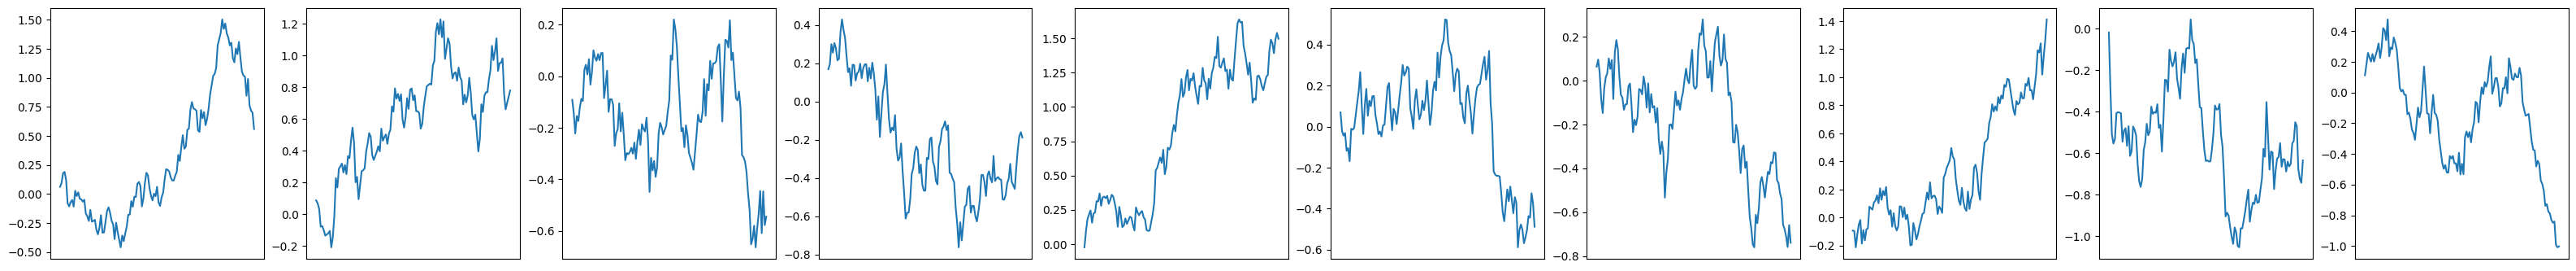

Increments


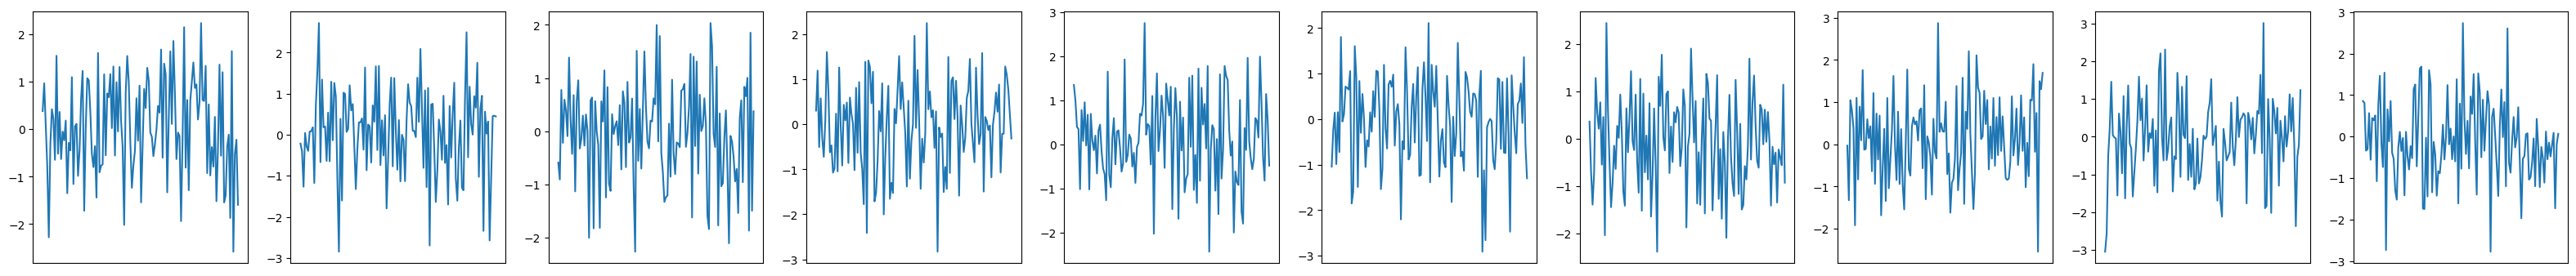

In [17]:
print("Raw time series, Brownian motion") 
plot_time_series_row(raw, 10)
print("Increments") 
plot_time_series_row(x1, 10)

## Resolve experiment output

Same `resolve_or_setup_experiment_output` as `run_SDE.py`, at the same point
in the pipeline (right after `x1` is built) — this is what makes everything
below land in the *exact* same `gaussian_experiment/experiments/<config>/`
and `saved_results/` folders, under the same filenames, as running
`run_SDE.py` with these arguments would. It also reuses a saved run if one
with matching parameters already exists (set `args.force_rerun = True` above
to ignore that and rerun from scratch).


In [18]:
config, exp_dir, fig_dir, potentials_dir, logger, loaded = resolve_or_setup_experiment_output(
    outdir, args, M, device, coarse_grained=False,
    extra_metadata={'M': M, 'B': B, 'channels': channels},
    include_potentials_dir=True,
)
print('config:', config)
print('exp_dir:', exp_dir)


2026-08-31 18:17:33  INFO      Config: gaussiansynth_H0.5_intermittency0.0_M128_J7_Q1_sigma1.0_nt500_n1_1000_lam5e-06_seed_0_termsed1bd1e1_order_1_and_2
2026-08-31 18:17:33  INFO      Experiment folder: /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/gaussian_experiment/experiments/gaussiansynth_H0.5_intermittency0.0_M128_J7_Q1_sigma1.0_nt500_n1_1000_lam5e-06_seed_0_termsed1bd1e1_order_1_and_2
2026-08-31 18:17:33  INFO      Arguments: {'timestamp': None, 'n1': 1000, 'M': 128, 'hurst': 0.5, 'intermittency': 0.0, 'J': 7, 'Q': 1, 'terms': ['Scattering_First_Order', 'Scattering_Second_Order'], 'nt': 500, 'sigma': 1.0, 'schedule_exponent': 2, 'interpolant': 'Cos', 'regularization': 0.01, 'lam': 5e-06, 'n_subsample': 1, 'batch_size': None, 'n_traj_groups': 2, 'n_tau': 30, 'moment_threshold': 1e-08, 'n_acf_lags': 40, 'outdir': None, 'label': 'order_1_and_2', 'force_rerun': False, 'no_save_aux_moments': False, 'seed': 0}
config: gaussiansynth_H0.5_intermittency0.0_M

config: gaussiansynth_H0.5_intermittency0.0_M128_J7_Q3_sigma0.3_nt100_n1_100_lam5e-06_seed_0_terms9559d19a_notebook_check
exp_dir: /home/chiaraz/phd/MGD-for-Maximum-Entropy-Generation/gaussian_experiment/experiments/gaussiansynth_H0.5_intermittency0.0_M128_J7_Q3_sigma0.3_nt100_n1_100_lam5e-06_seed_0_terms9559d19a_notebook_check


## Increment sanity check

Identical to `plot_increment_diagnostics()` in `run_SDE.py` — writes
`figures/increment_diagnostics.png` into `fig_dir` exactly as the script
does, then redisplays that same file inline (plotting functions here either
save-to-disk or show inline, never both, so redisplaying the saved file is
how this notebook gets both without diverging from the script's code path).


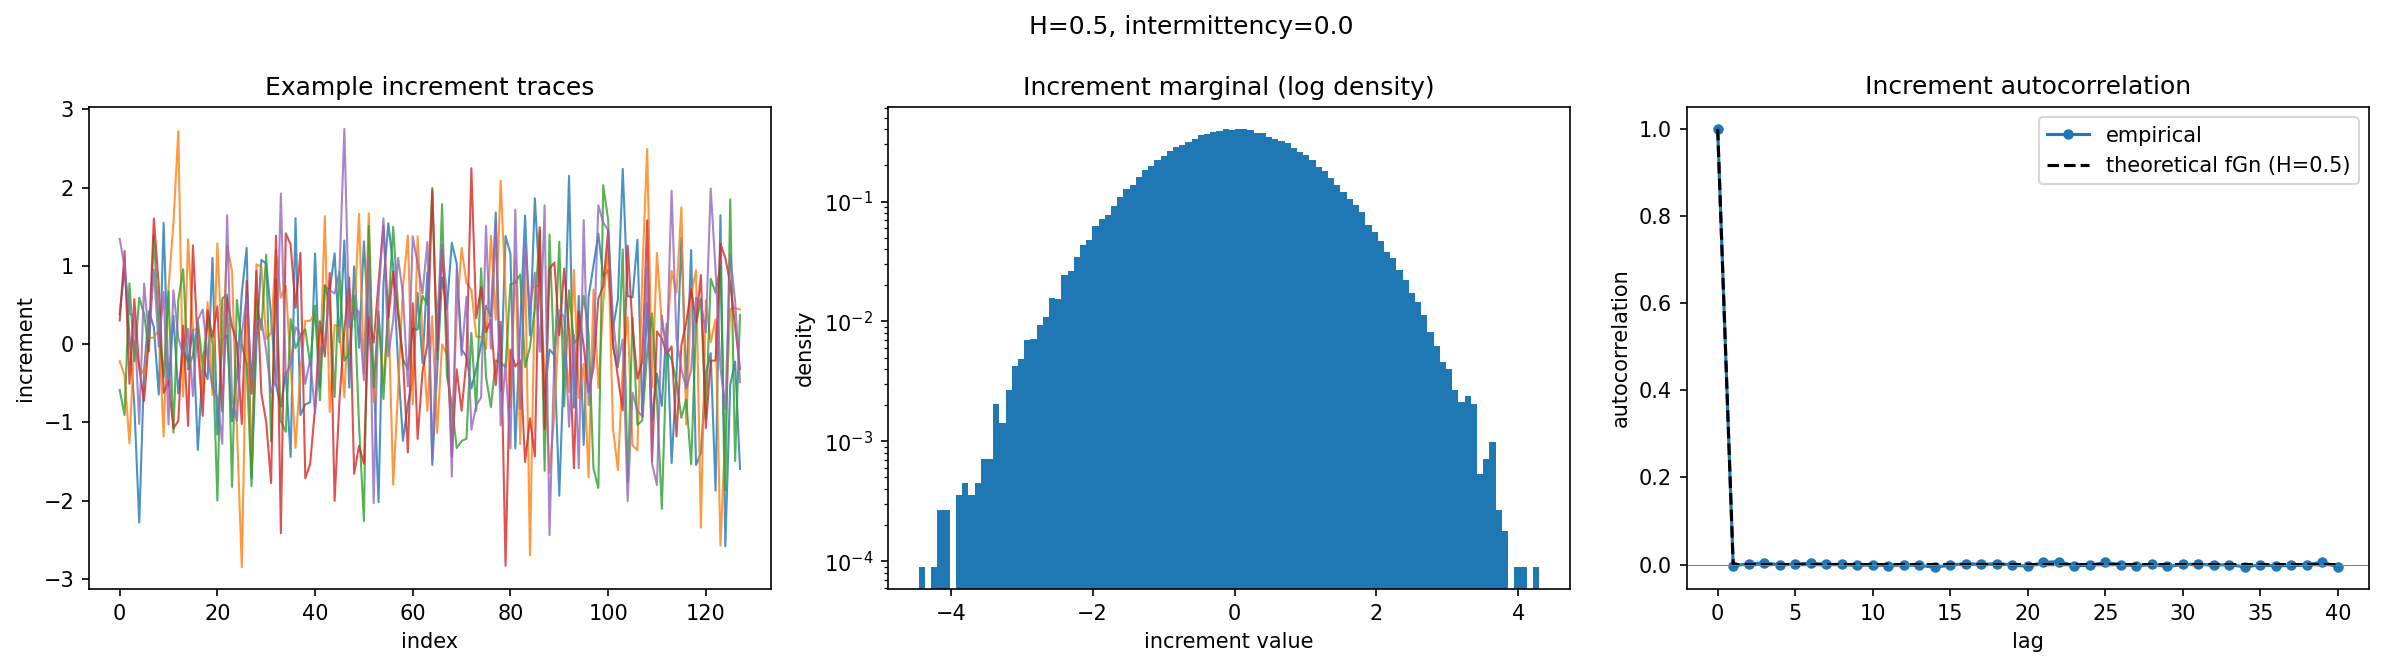

In [19]:
%matplotlib inline
def plot_increment_diagnostics(x1, args, fig_dir, config, n_show=5):
    x = x1[:, 0, :].detach().cpu().numpy()
    B, M = x.shape
    max_lag = min(args.n_acf_lags, M - 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for i in range(min(n_show, B)):
        axes[0].plot(x[i], lw=1, alpha=0.8)
    axes[0].set_title('Example increment traces')
    axes[0].set_xlabel('index'); axes[0].set_ylabel('increment')

    axes[1].hist(x.ravel(), bins=100, density=True, log=True)
    axes[1].set_title('Increment marginal (log density)')
    axes[1].set_xlabel('increment value'); axes[1].set_ylabel('density')

    x_centered = x - x.mean()
    var = x_centered.var()
    acf_emp = np.array([
        1.0 if lag == 0 else
        np.mean(x_centered[:, :M - lag] * x_centered[:, lag:]) / var
        for lag in range(max_lag + 1)
    ])
    k = np.arange(0, max_lag + 1)
    acf_theory = 0.5 * (
        np.abs(k + 1) ** (2 * args.hurst)
        - 2 * np.abs(k) ** (2 * args.hurst)
        + np.abs(k - 1) ** (2 * args.hurst)
    )
    acf_theory[0] = 1.0

    axes[2].plot(k, acf_emp, 'o-', ms=4, label='empirical')
    axes[2].plot(k, acf_theory, 'k--', label=f'theoretical fGn (H={args.hurst})')
    axes[2].axhline(0, color='grey', lw=0.5)
    axes[2].set_xlabel('lag'); axes[2].set_ylabel('autocorrelation')
    axes[2].legend()
    axes[2].set_title('Increment autocorrelation')

    fig.suptitle(f'H={args.hurst}, intermittency={args.intermittency}', fontsize=12)
    fig.tight_layout()
    fig.savefig(fig_dir / 'increment_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

plot_increment_diagnostics(x1, args, fig_dir, config)
display(Image(filename=str(fig_dir / 'increment_diagnostics.png')))


If the setup is correct: the middle panel is a symmetric Gaussian-looking
histogram when `intermittency=0` (fat-tailed once `intermittency>0`), and
the right panel's empirical curve should track the theoretical fGn curve
closely — a mismatch there means `hurst`/`intermittency` aren't doing what
you expect.


## Filters & potentials

In [20]:
filters, filters_Phi = return_Filters(M, args.J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, args.J, args.Q, device=device)

t = 1 - (1 - torch.linspace(0, 1, args.nt + 1)) ** args.schedule_exponent
t_rounded = torch.round(t, decimals=4)
t_final = int((t_rounded == 1.0).nonzero(as_tuple=True)[0][0])
print(f"t_final = {t_final}/{len(t)} (last t = {t[t_final-1].item():.6f}, "
      f"dropping {len(t) - t_final} redundant trailing points at 1.0000)")


t_final = 497/501 (last t = 0.999936, dropping 4 redundant trailing points at 1.0000)


## Run or load the SDE

In [21]:
fig_dir.mkdir(parents=True, exist_ok=True)

In [22]:
if loaded is not None:
    print('Loaded existing results (no SDE run).')
    result = loaded
else:
    result = run_experiment(args, M, config, x1, filters,
                            t[:t_final], logger, outdir, device,
                            filters_Q=filters_Q, filters_Phi=filters_Phi,
                            potentials_save_dir=potentials_dir,
                            )


2026-08-31 18:17:39  INFO      Running experiment: gaussiansynth_H0.5_intermittency0.0_M128_J7_Q1_sigma1.0_nt500_n1_1000_lam5e-06_seed_0_termsed1bd1e1_order_1_and_2
2026-08-31 18:17:39  INFO      terms: ['Scattering_First_Order', 'Scattering_Second_Order']
Signal detected as 1D: (B, C, T) = (1000, 1, 128).
The model has 15 potentials.
The model has 15 potentials.


496it [00:03, 150.32it/s]


Loop finished
After loop: CPU=1.06 GB | GPU alloc=0.04 GB | GPU reserved=0.11 GB
Preparing regularised solve
Before _solve_regularised: CPU=1.06 GB | GPU alloc=0.04 GB | GPU reserved=0.11 GB
Dropped close-in-time nodes: 0
Last times: [0.999744   0.99980402 0.999856   0.99989998 0.99993598]
Last dt: [6.00218773e-05 5.19752502e-05 4.39882278e-05 3.60012054e-05]
Calling torch.linalg.solve
Before solve: CPU=1.09 GB | GPU alloc=0.45 GB | GPU reserved=0.93 GB
Solve finished
After solve: CPU=1.12 GB | GPU alloc=0.45 GB | GPU reserved=0.93 GB
After _solve_regularised: CPU=1.12 GB | GPU alloc=0.04 GB | GPU reserved=0.93 GB
Stacking outputs
Everything stacked: CPU=1.12 GB | GPU alloc=0.04 GB | GPU reserved=0.93 GB
Returning
2026-08-31 18:17:44  INFO      SDE integration finished in 4.3 s


## Diagnostics

Same calls, same `save={"filename": ..., "title": ...}` dicts, same
filenames under `fig_dir`, as `save_diagnostics()` in `run_SDE.py` — each
one written to disk first, then redisplayed inline via the saved file
(matches the docstring note above: these functions save-or-show, never
both).

Note: `spec_plot`'s `save=` argument is a no-op upstream (in
`codes/check_moments.py` — it never reads `save["filename"]`), so, exactly
like `run_SDE.py`, no `spectrum.png` is written here either. It still
displays inline below via its own internal `plt.show()`, just isn't
persisted — this is a pre-existing bug in shared code, not something this
notebook does differently from the script.


### Wavelet coefficient histograms

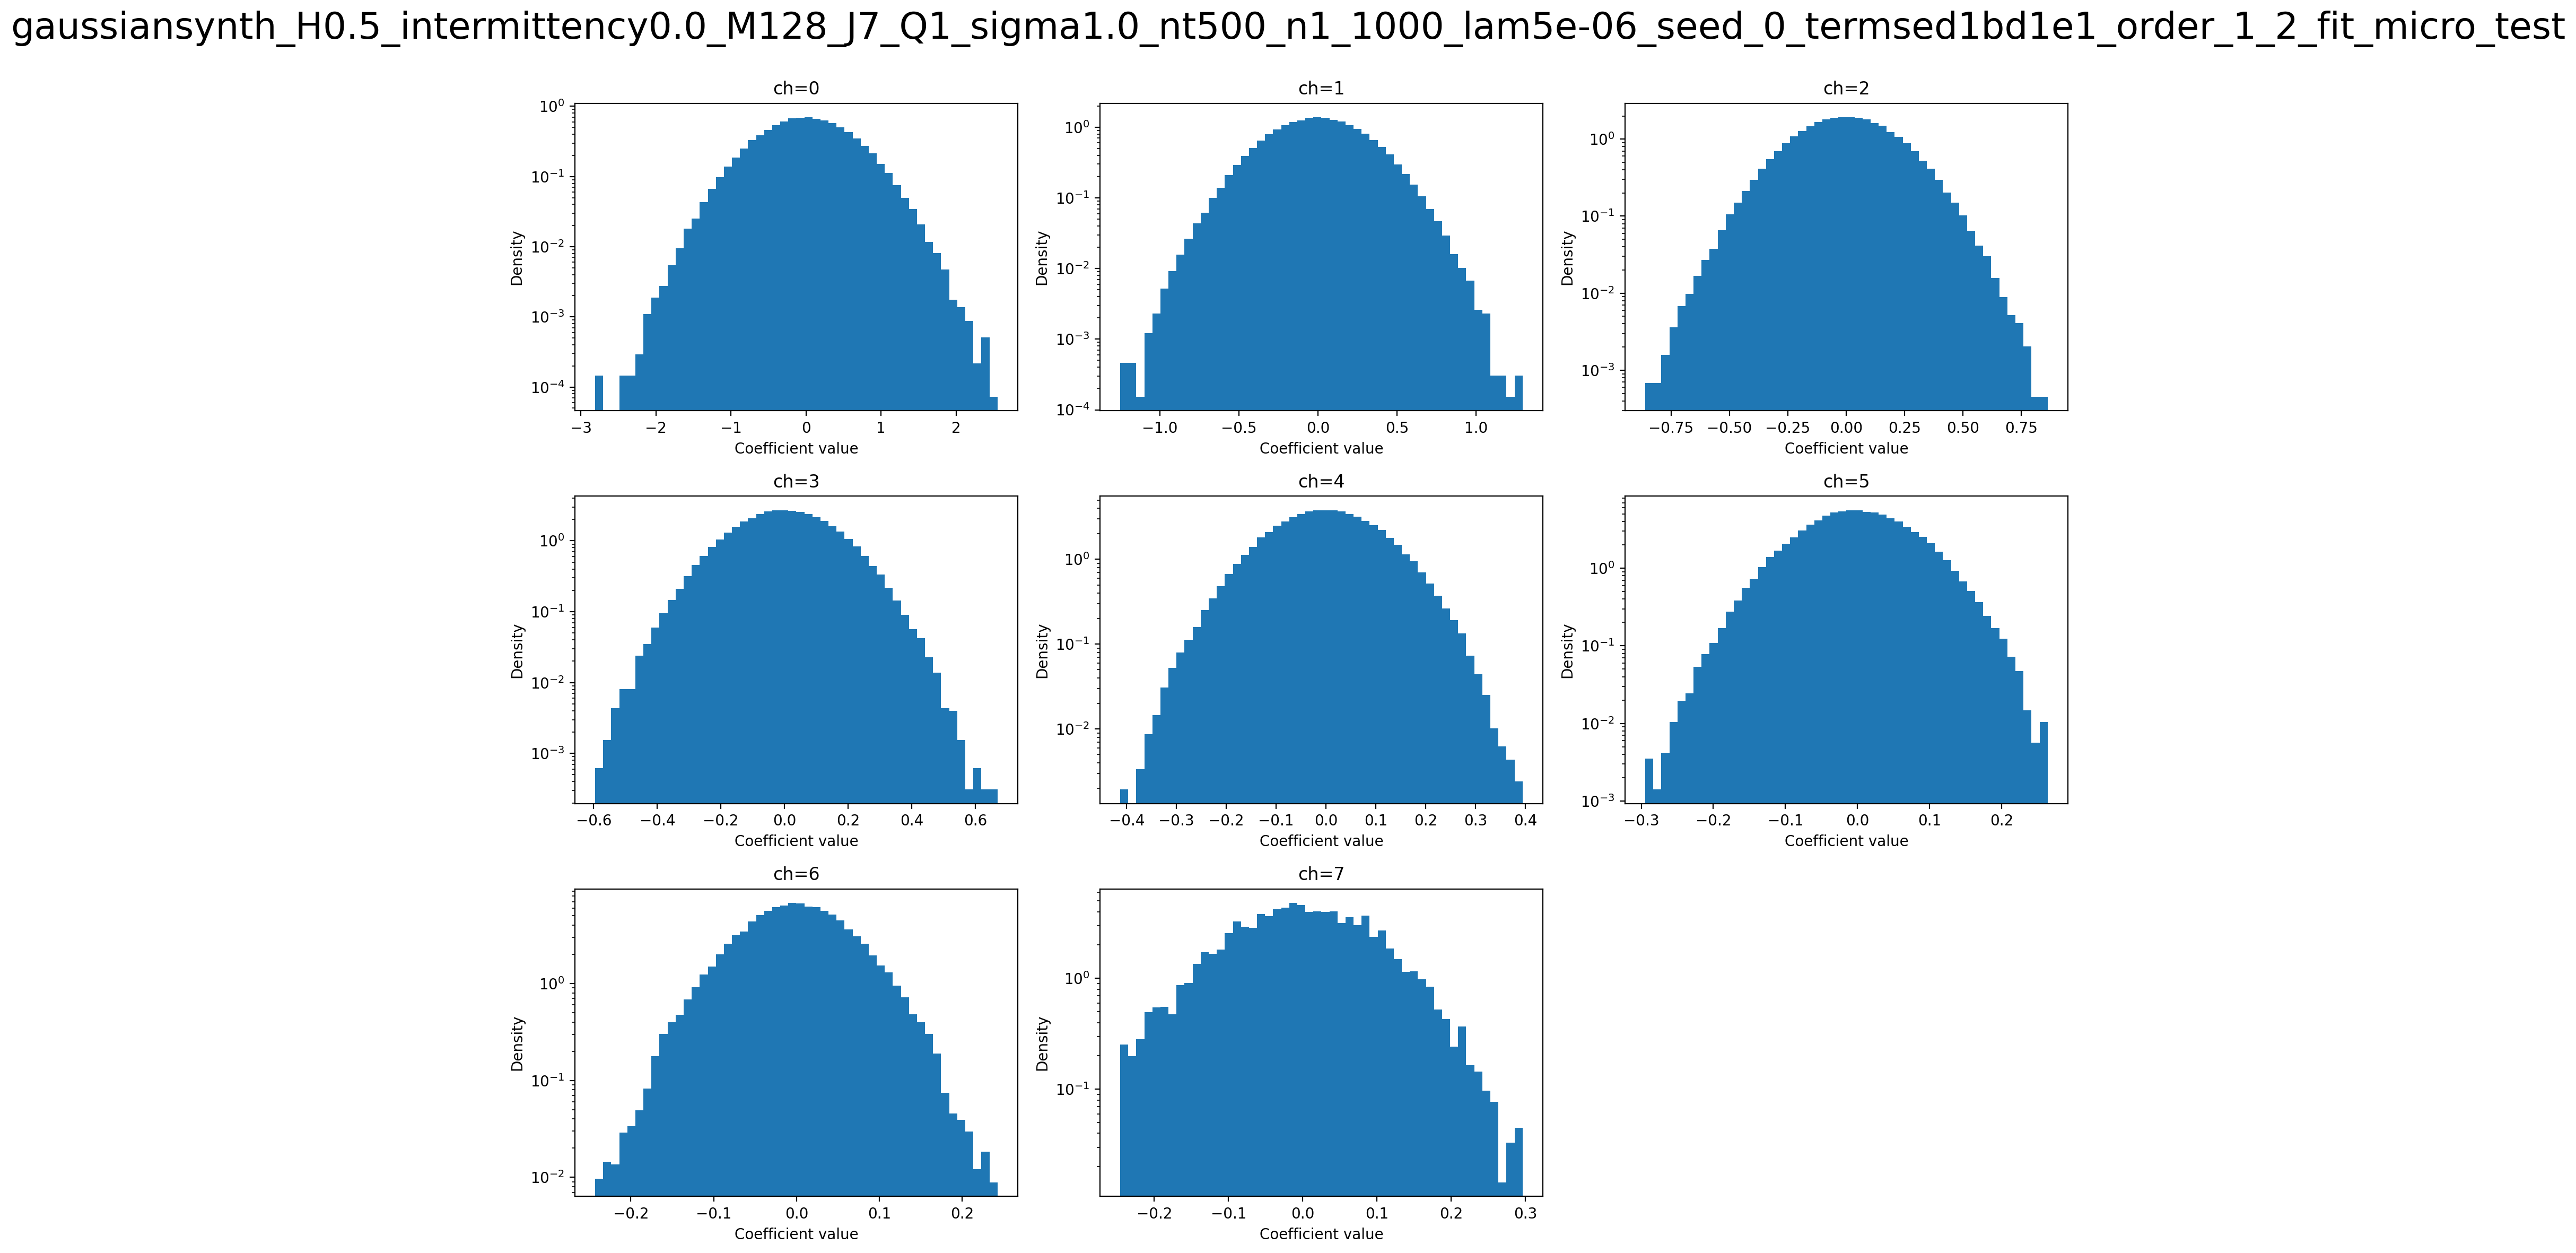

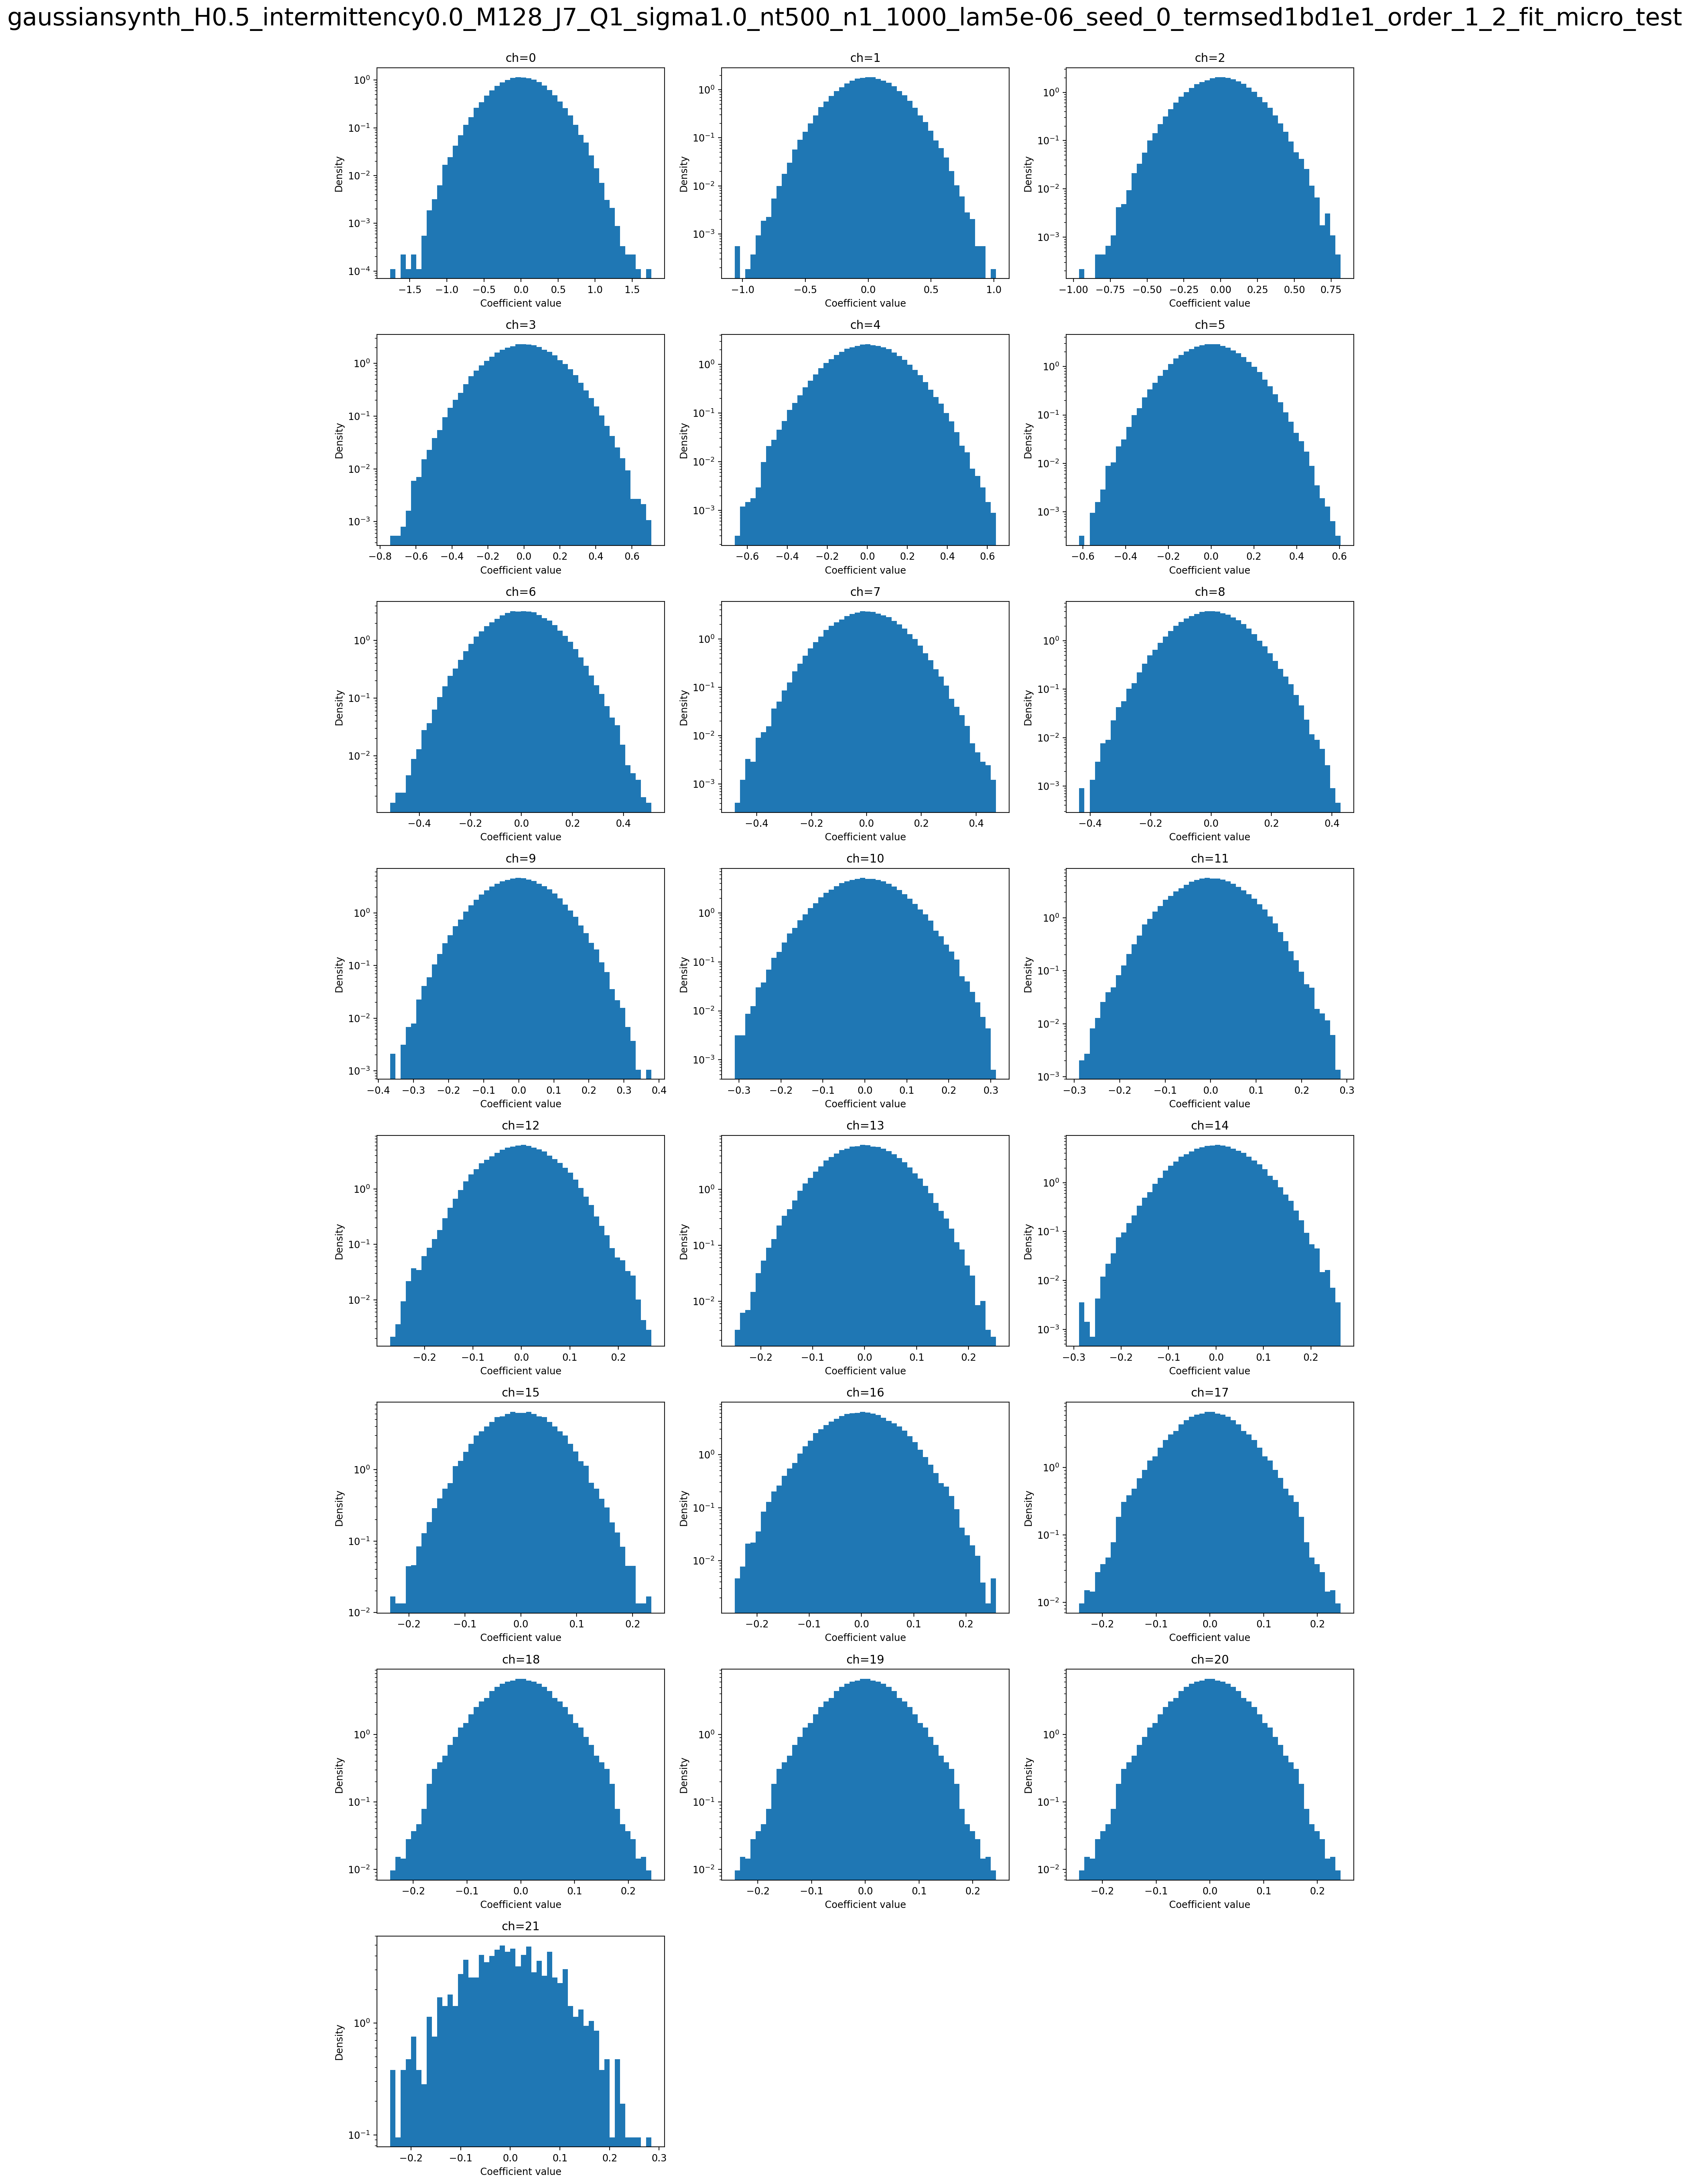

In [12]:
%matplotlib inline
def plot_wavelet_coeff_histograms(x1, J, Q, config, figdir, logger, save=None):
    B, channels, M = x1.shape
    filters = return_Filters(M, J, Q, device=device)
    wt = torch.fft.ifft(torch.fft.fft(x1) * filters).real  # (B, J, T)
    n_wavelets = filters.shape[1]

    ncols = 3
    nrows = math.ceil(n_wavelets / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i in range(n_wavelets):
        vals = wt[:, i, :].detach().cpu().flatten().numpy()
        axes[i].hist(vals, bins=50, density=True, log=True)
        axes[i].set_title(f"ch={i}")
        axes[i].set_xlabel("Coefficient value")
        axes[i].set_ylabel("Density")

    for j in range(n_wavelets, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Wavelet coefficient histograms (Q={Q})", fontsize=25)

    if save is not None:
        fig.suptitle(save["title"], fontsize=25)
        fig.tight_layout(rect=[0, 0, 1, 0.98])
        fig.savefig(save["filename"], dpi=200, bbox_inches="tight")
        plt.close(fig)
    else:
        fig.tight_layout()
        plt.show()

plot_wavelet_coeff_histograms(
    x1, args.J, 1, config, fig_dir, logger,
    save={"filename": fig_dir / "wavelet_histo_Q1.png", "title": config}
)
display(Image(filename=str(fig_dir / "wavelet_histo_Q1.png")))

plot_wavelet_coeff_histograms(
    x1, args.J, 3, config, fig_dir, logger,
    save={"filename": fig_dir / "wavelet_histo_Q3.png", "title": config}
)
display(Image(filename=str(fig_dir / "wavelet_histo_Q3.png")))


### Moment matching

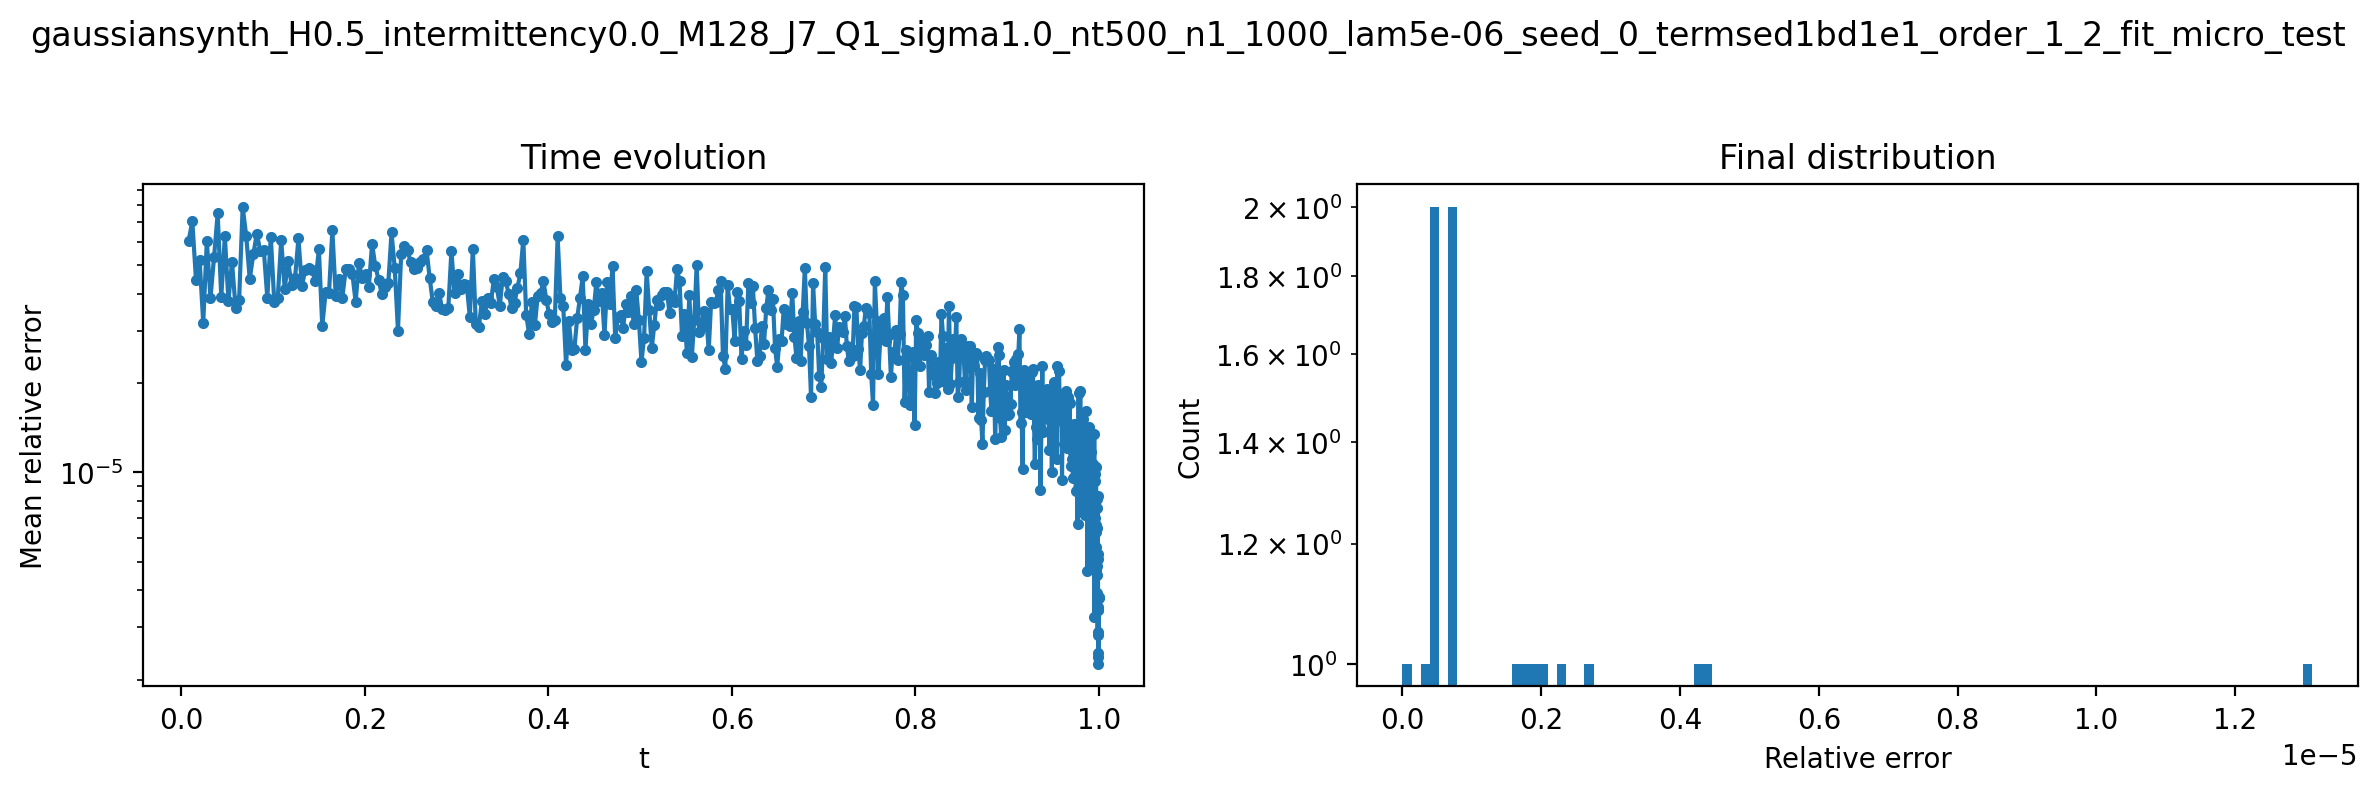

In [13]:
%matplotlib inline
if result.get('barphi_e') is not None and result.get('barphi_p') is not None:
    plot_moment_matching(result['barphi_e'], result['barphi_p'], result['t'], args.moment_threshold,
                          save={"filename": fig_dir / "moment_matching.png", "title": config})
    display(Image(filename=str(fig_dir / "moment_matching.png")))
else:
    print('No aux moments available (loaded a run without the saved aux file?); skipping.')


### True vs synthesized trajectories

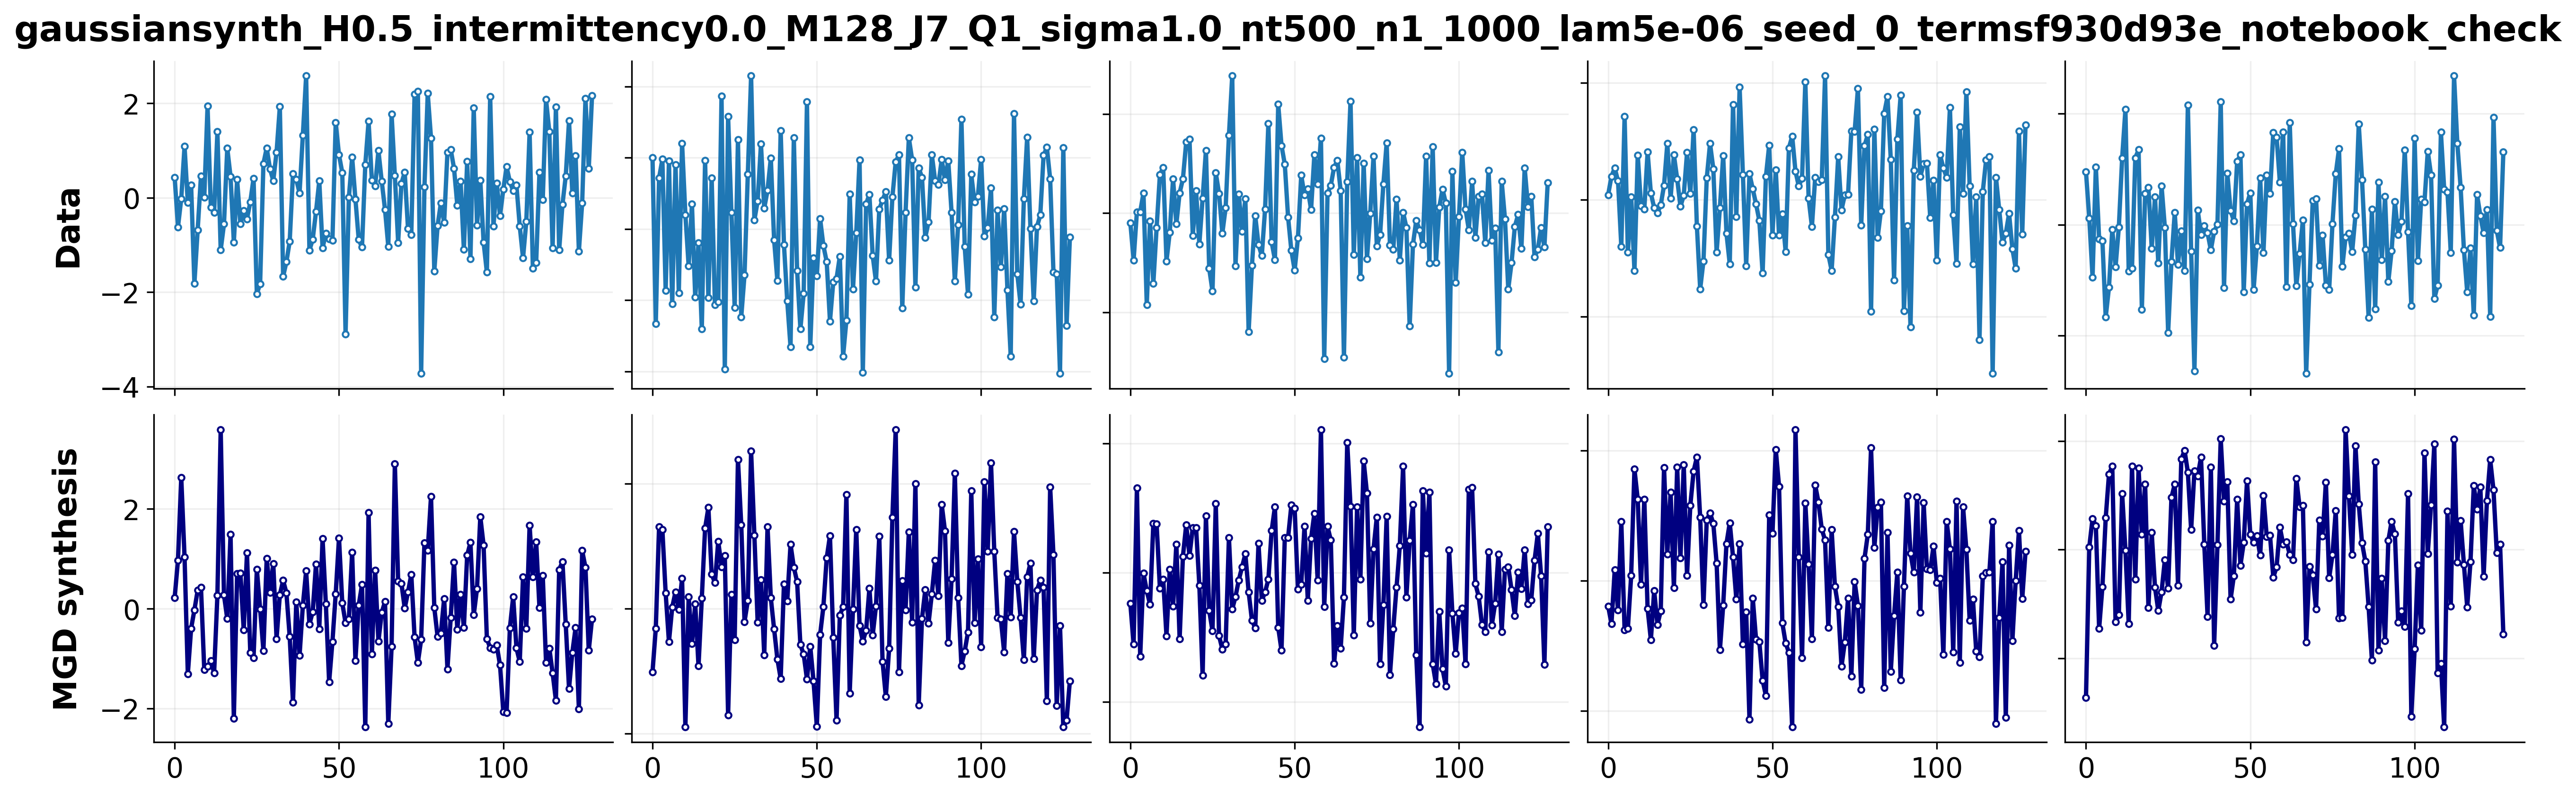

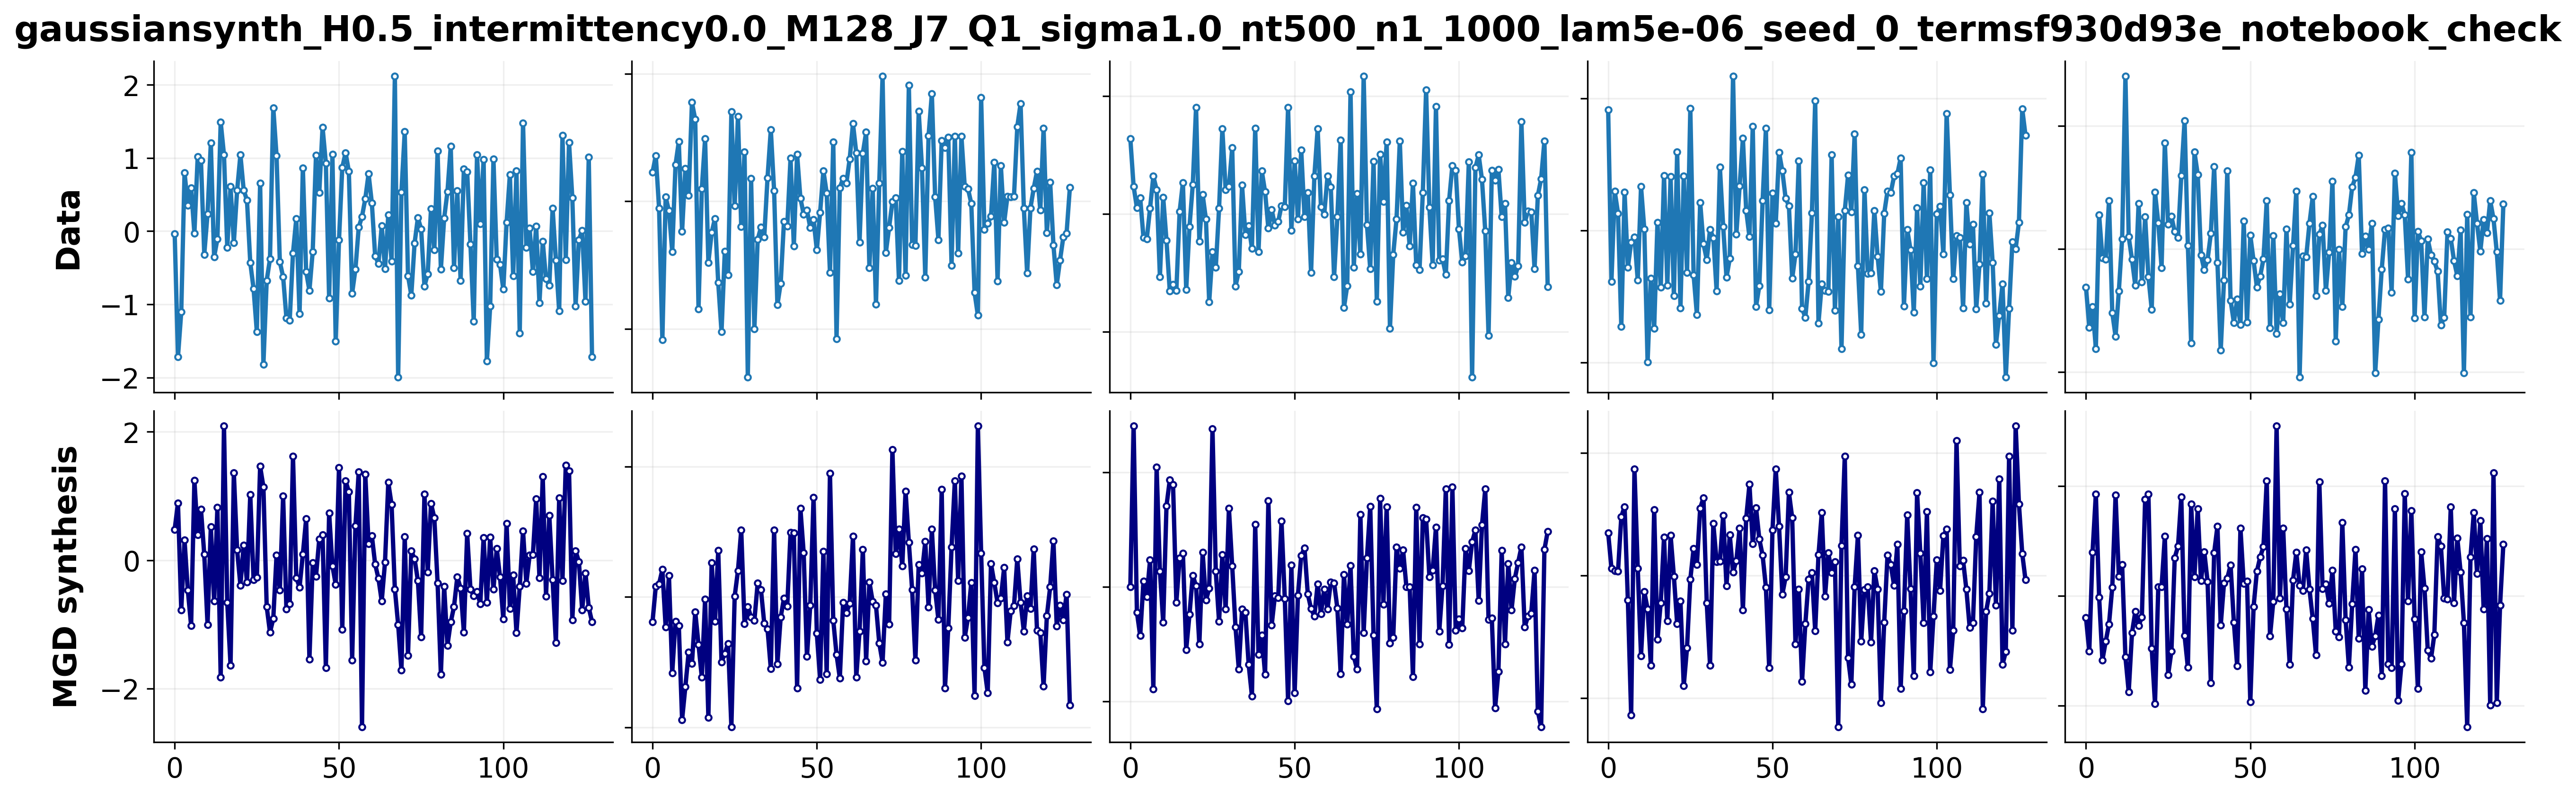

In [13]:
%matplotlib inline
n_groups = max(1, min(args.n_traj_groups, x1.shape[0] // 5))
for i in range(n_groups):
    Compare_time_series_row(x1[i*5:i*5+5], result['xt'][i*5:i*5+5], 5,
                             save={"filename": fig_dir / "compare_time_series.png", "title": config})
    display(Image(filename=str(fig_dir / "compare_time_series.png")))


### Histograms, spectrum, structure functions

(`spec_plot` displays inline but — see note above — writes no file.)


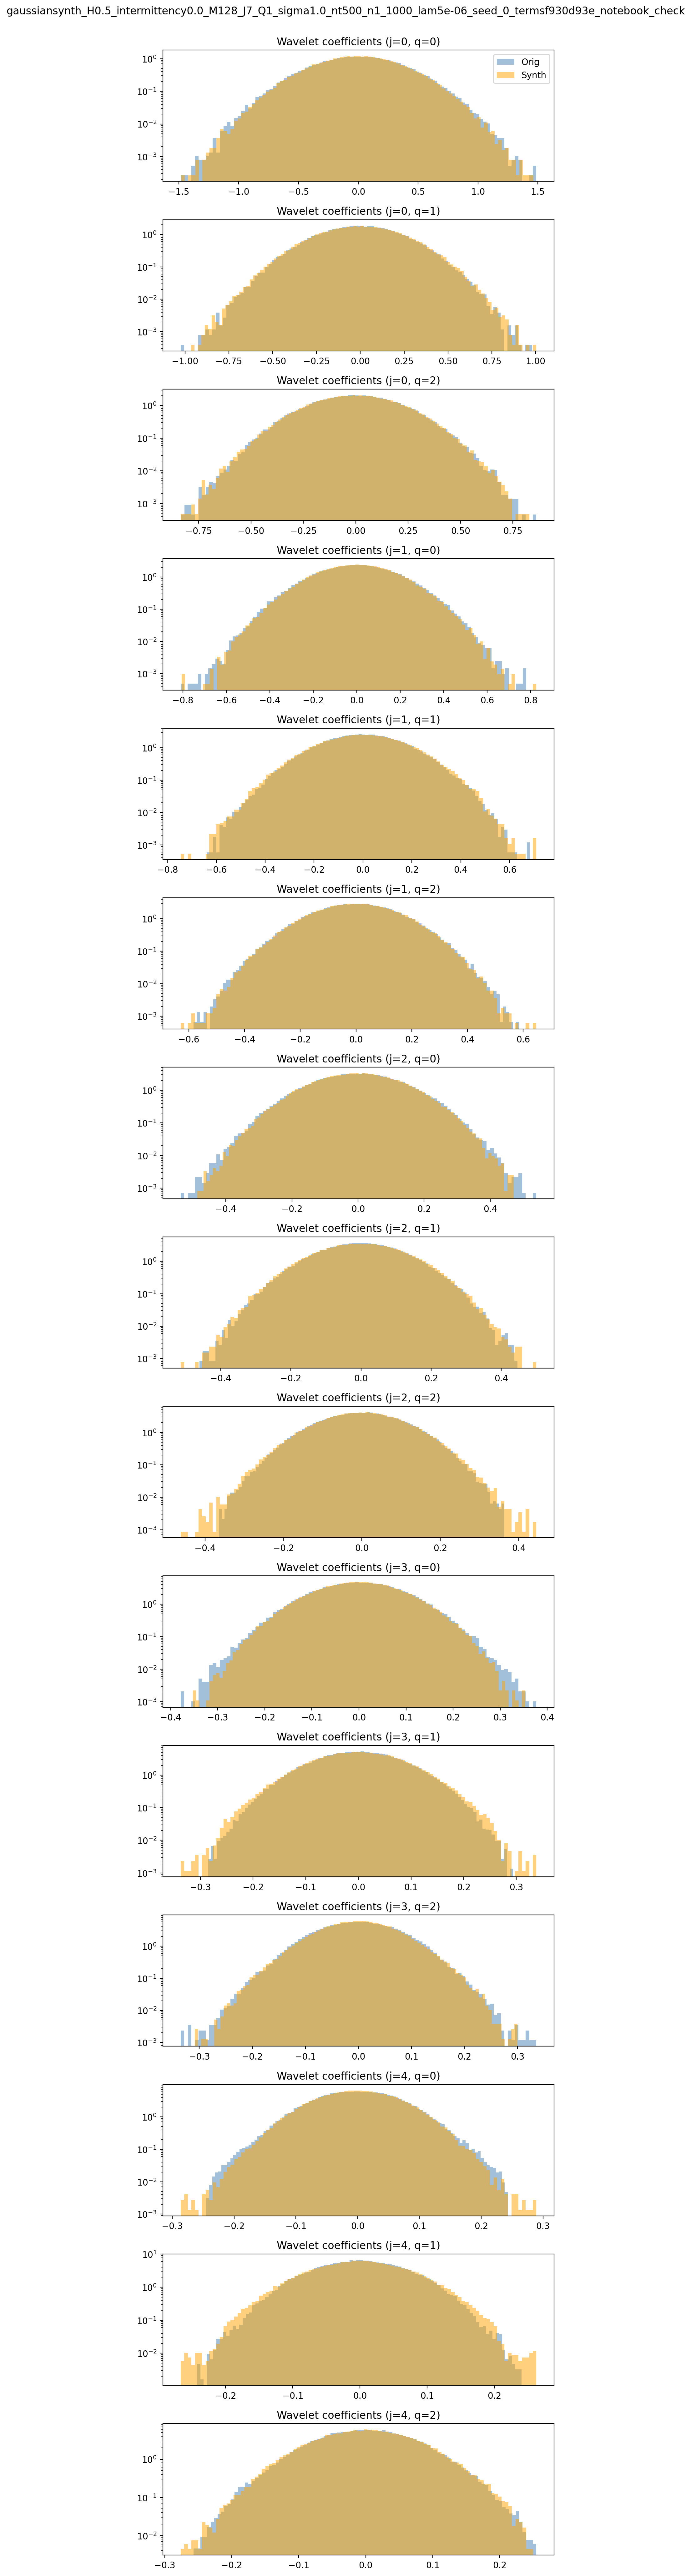

In [14]:
%matplotlib inline
hist_plot(x1, result['xt'], save={"filename": fig_dir / "histograms.png", "title": config})
display(Image(filename=str(fig_dir / "histograms.png")))


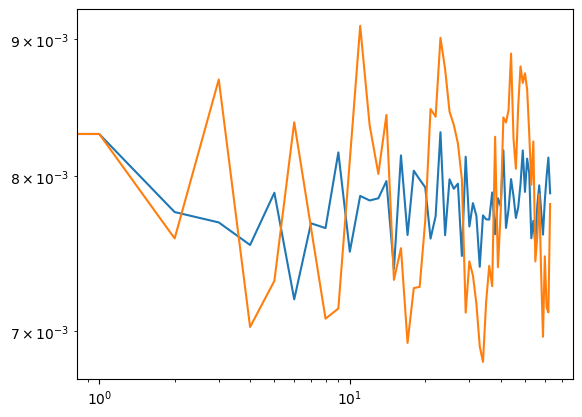

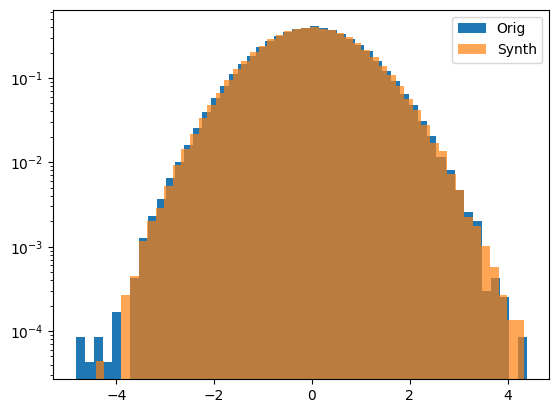

In [15]:
%matplotlib inline
spec_plot(x1, result['xt'], save={"filename": fig_dir / "spectrum.png", "title": config})


Computing structure functions for 63 lags...
Computing structure functions for 63 lags...


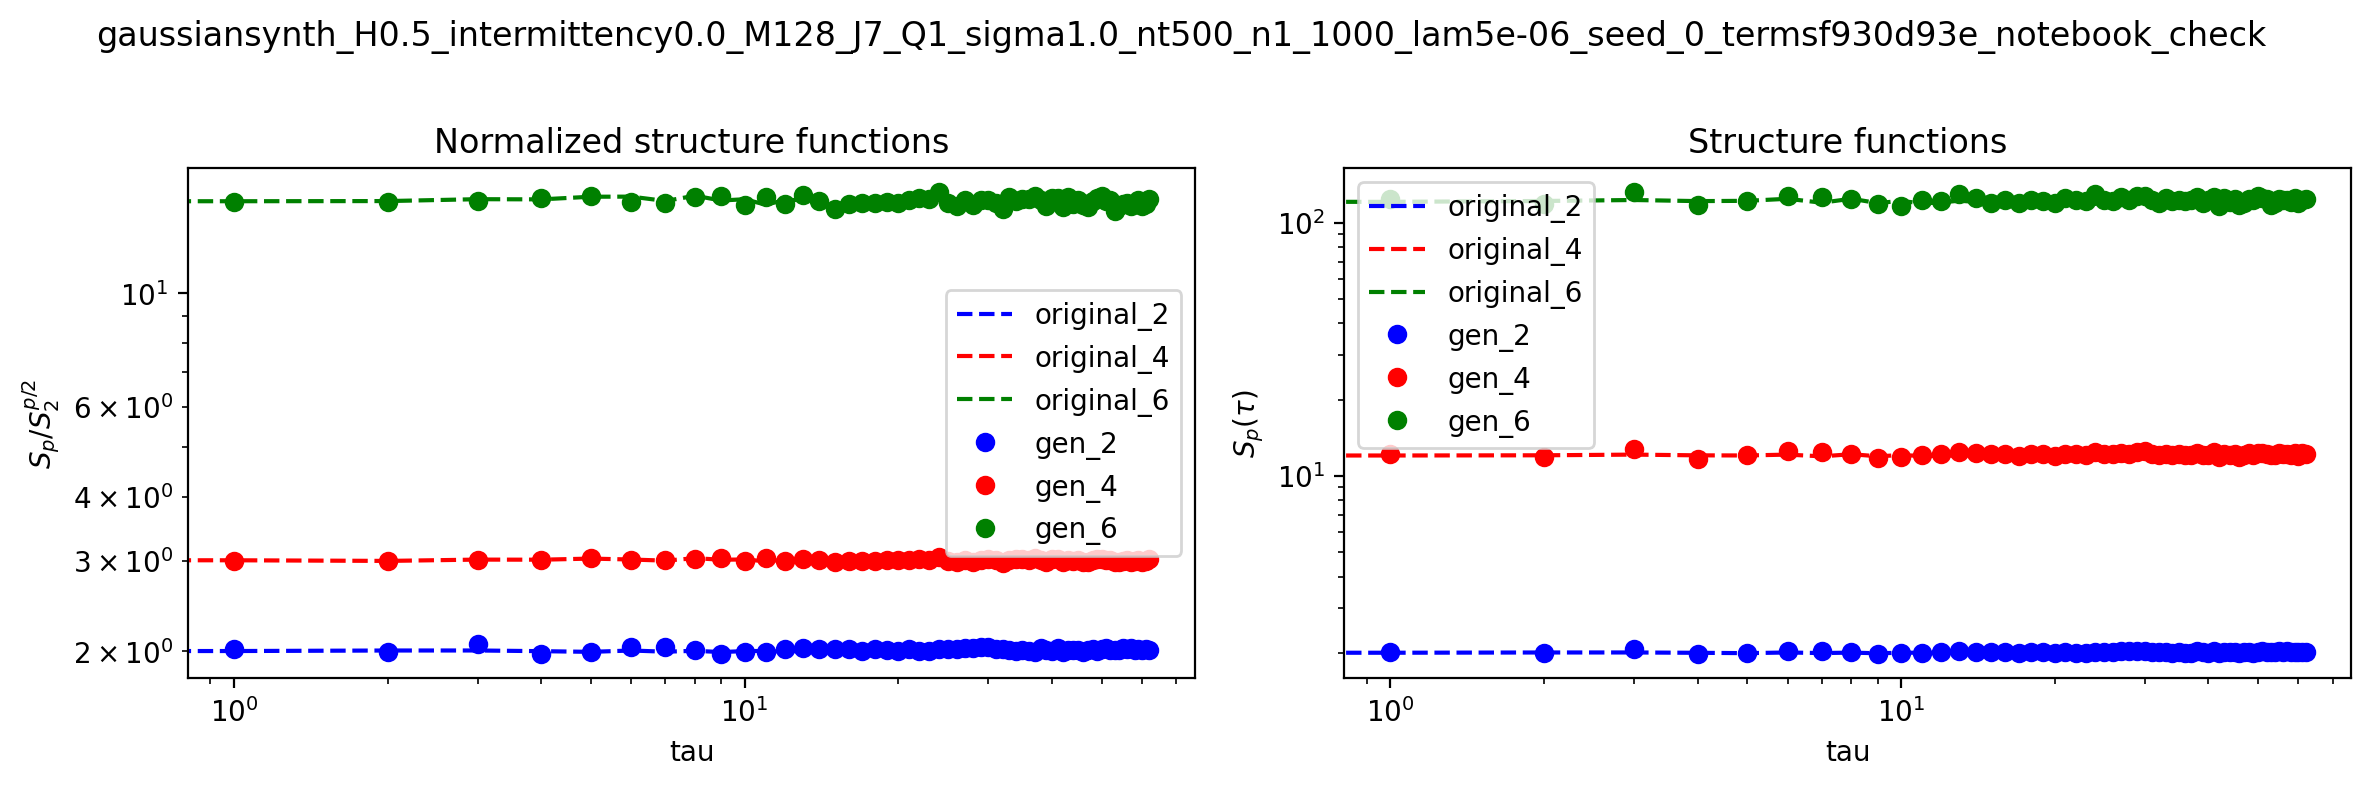

In [16]:
%matplotlib inline
structure_plot(x1, result['xt'], save={"filename": fig_dir / "structure_functions.png", "title": config})
display(Image(filename=str(fig_dir / "structure_functions.png")))


## Verify against `run_SDE.py`'s output

Sanity check that this notebook wrote exactly the files `run_SDE.py` would
for the same config (same folder, same names) — should print the same 8
filenames both scripts produce (`spectrum.png` excluded for the reason
above).


In [16]:
sorted(p.name for p in fig_dir.glob('*.png'))


['compare_time_series.png',
 'histograms.png',
 'increment_diagnostics.png',
 'moment_matching.png',
 'scaling_exponent_ratio.png',
 'structure_functions.png',
 'wavelet_histo_Q1.png',
 'wavelet_histo_Q3.png']